 # Toyota Corolla Price Analysis

 ## 1. Overview

 Columns:
 - Age: Age in years
 - KM: Accumulated Kilometers on odometer
 - FuelType: Fuel Type (Petrol, Diesel, CNG)
 - HP: Horse Power
 - MetColor: Metallic Color? (Yes=1, No=0)
 - Automatic: Automatic (Yes=1, No=0)
 - CC: Cylinder Volume in cubic centimeters
 - Doors: Number of doors
 - Weight: Weight in Kilograms
 - Price: Offer Price in EUROs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')


In [2]:
dataset = pd.read_csv('./ToyotaCorolla.csv')


selected_columns = ['Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Met_Color', 'Automatic', 'CC', 'Doors', 'Weight', 'Price']
dataset = dataset[selected_columns]

dataset.head()
display( dataset.count())
display( dataset.describe())
display( dataset.isnull().sum())

Age_08_04    1436
KM           1436
Fuel_Type    1436
HP           1436
Met_Color    1436
Automatic    1436
CC           1436
Doors        1436
Weight       1436
Price        1436
dtype: int64

,Age_08_04,KM,HP,Met_Color,Automatic,CC,Doors,Weight,Price
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.00000,1436.000000
mean,55.947075,68533.259749,101.502089,0.674791,0.055710,1576.85585,4.033426,1072.45961,10730.824513
std,18.599988,37506.448872,14.981080,0.468616,0.229441,424.38677,0.952677,52.64112,3626.964585
min,1.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,2.000000,1000.00000,4350.000000
25%,44.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,3.000000,1040.00000,8450.000000
50%,61.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,4.000000,1070.00000,9900.000000
75%,70.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,5.000000,1085.00000,11950.000000
max,80.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,5.000000,1615.00000,32500.000000


Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Met_Color    0
Automatic    0
CC           0
Doors        0
Weight       0
Price        0
dtype: int64

 ## 2. EDA & Corr analysis

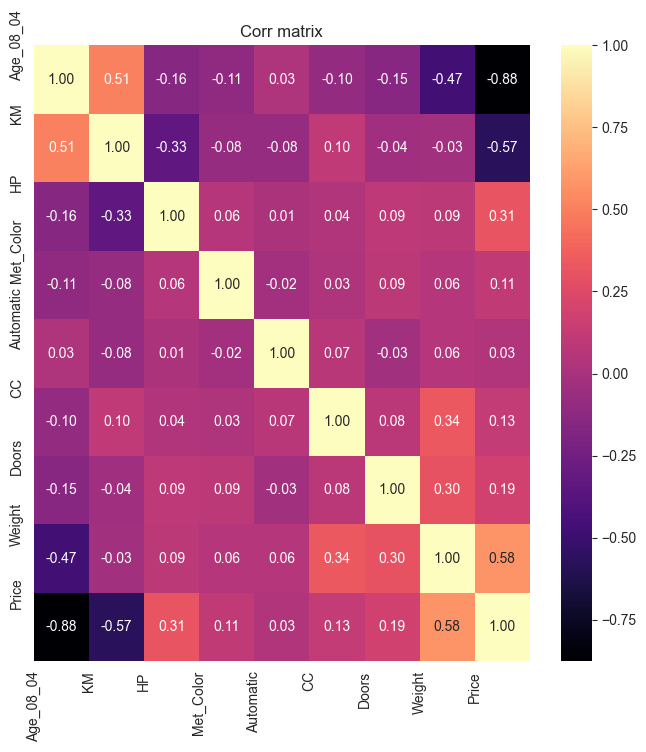

In [3]:
corr = dataset.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Corr matrix")
plt.show()

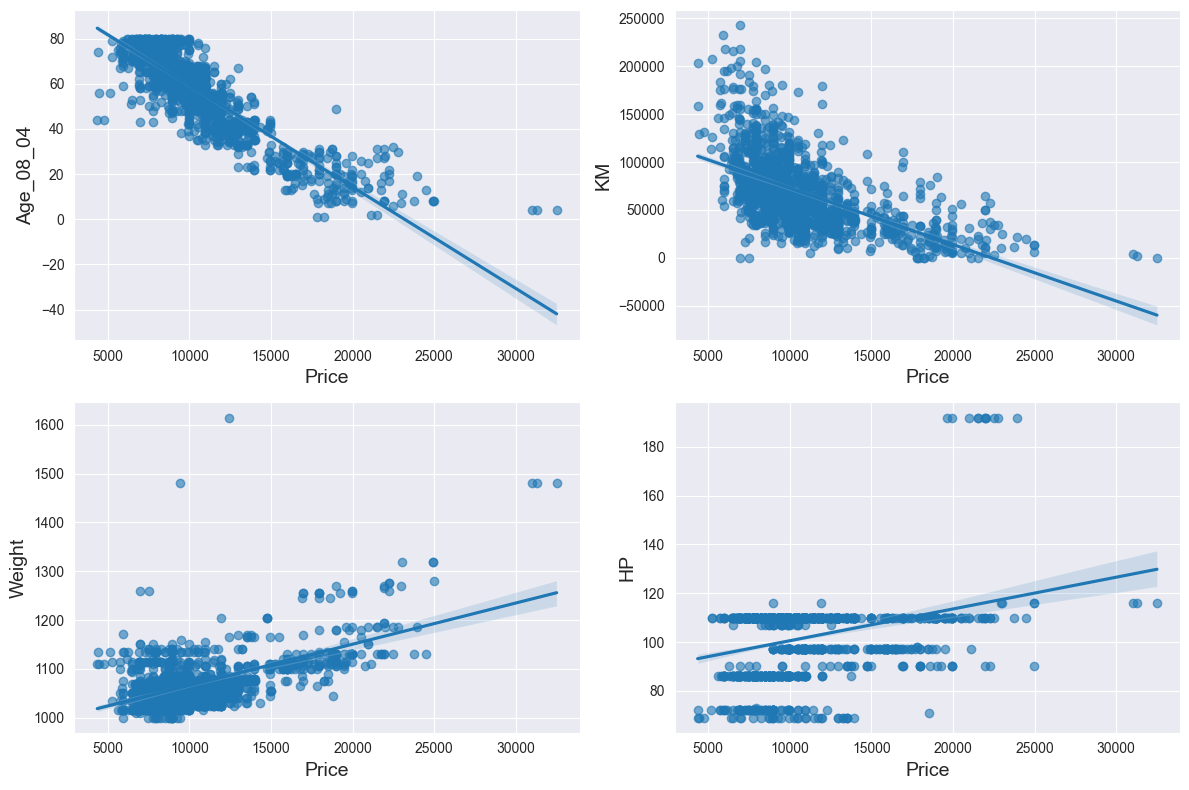

In [4]:
f, axes = plt.subplots(2, 2, figsize=(12,8))

sns.regplot(x='Price', y='Age_08_04', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[0,0])
axes[0,0].set_xlabel('Price', fontsize=14)
axes[0,0].set_ylabel('Age_08_04', fontsize=14)

sns.regplot(x='Price', y='KM', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[0,1])
axes[0,1].set_xlabel('Price', fontsize=14)
axes[0,1].set_ylabel('KM', fontsize=14)

sns.regplot(x='Price', y='Weight', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[1,0])
axes[1,0].set_xlabel('Price', fontsize=14)
axes[1,0].set_ylabel('Weight', fontsize=14)

sns.regplot(x='Price', y='HP', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[1,1])
axes[1,1].set_xlabel('Price', fontsize=14)
axes[1,1].set_ylabel('HP', fontsize=14)

plt.tight_layout()
plt.show()

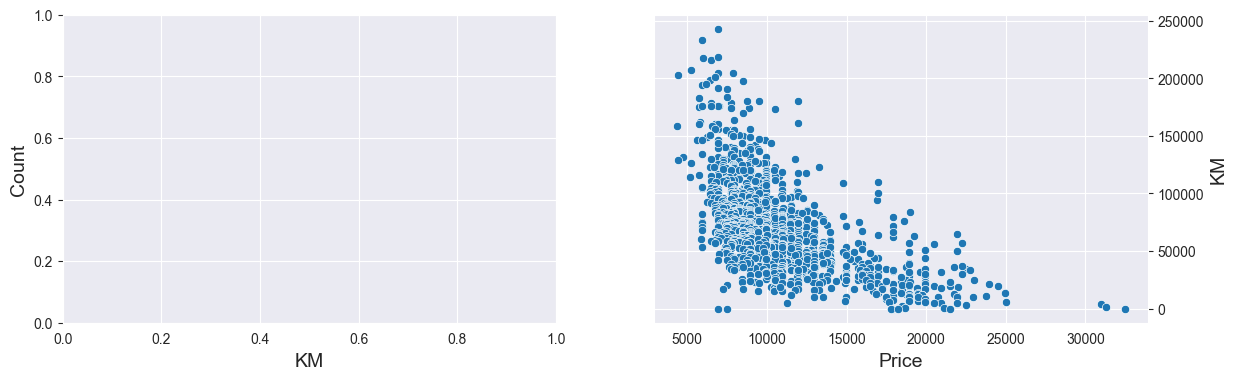

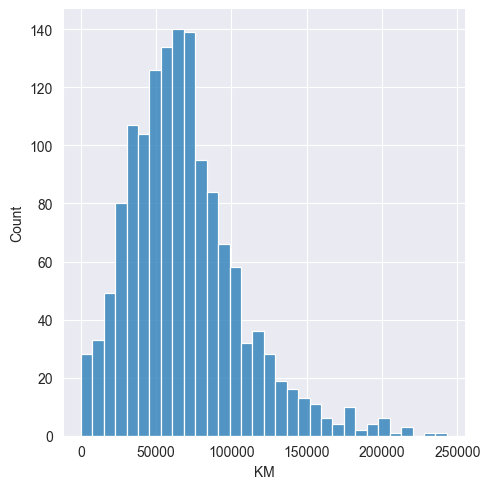

In [5]:
f, axes = plt.subplots(1,2,figsize=(14,4))

sns.displot(dataset['KM'], ax = axes[0])
axes[0].set_xlabel('KM', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()

sns.scatterplot(x = 'Price', y = 'KM', data = dataset, ax = axes[1])
axes[1].set_xlabel('Price', fontsize=14)
axes[1].set_ylabel('KM', fontsize=14)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.show()

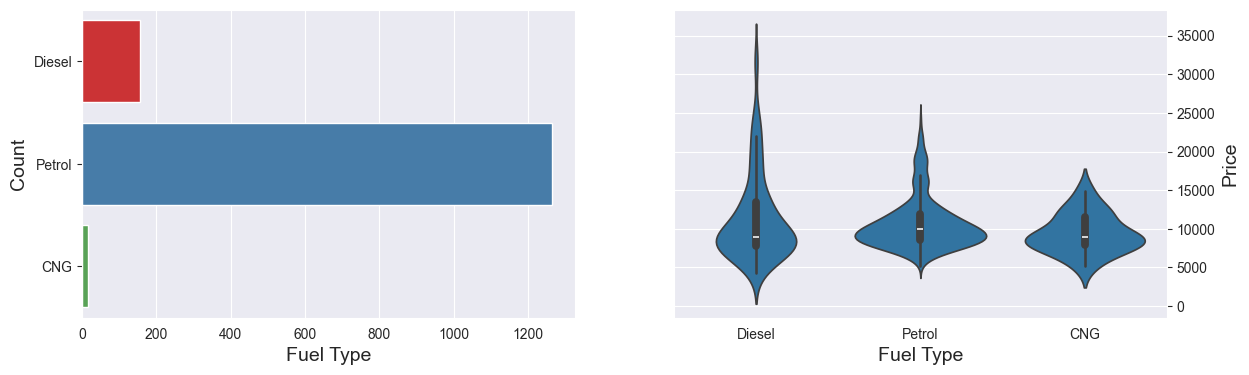

In [6]:
fuel_list= Counter(dataset['Fuel_Type'])
labels = fuel_list.keys()
sizes = fuel_list.values()

f, axes = plt.subplots(1,2,figsize=(14,4))

sns.countplot(dataset['Fuel_Type'], ax = axes[0], palette="Set1")
axes[0].set_xlabel('Fuel Type', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()

sns.violinplot(x = 'Fuel_Type', y = 'Price', data = dataset, ax = axes[1])
axes[1].set_xlabel('Fuel Type', fontsize=14)
axes[1].set_ylabel('Price', fontsize=14)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.show()

 ## 3. Data preparations

In [7]:
dataset_encoded = pd.get_dummies(dataset, drop_first=True)

X = dataset_encoded.drop('Price', axis=1).values
y = dataset_encoded['Price'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (1077, 10)
Shape of X_test:  (359, 10)


In [8]:
print(set(dataset['Fuel_Type']))
dataset_encoded.head()

{'Diesel', 'CNG', 'Petrol'}


,Age_08_04,KM,HP,Met_Color,Automatic,CC,Doors,Weight,Price,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23,46986,90,1,0,2000,3,1165,13500,True,False
1,23,72937,90,1,0,2000,3,1165,13750,True,False
2,24,41711,90,1,0,2000,3,1165,13950,True,False
3,26,48000,90,0,0,2000,3,1165,14950,True,False
4,30,38500,90,0,0,2000,3,1170,13750,True,False


 ## 4. Basic regression and 
residue analysis

In [9]:
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
]
regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train, y_train)

y_pred_linear_train = regressor_linear.predict(X_train)
y_pred_linear_test = regressor_linear.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=regressor_linear, X=X_train, y=y_train, cv=10)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

Linear Regression Results:
CV Mean:  -1398.0090134326056
R2_score (train):  0.9152895608025843
R2_score (test):  0.7722206348760974
RMSE:  1797.8852653329131
MAPE:  0.0945895072679307


 ### Residue analysis

In [10]:
y_train.ravel().shape
#(1077, 1) -> (1077,)

(1077,)

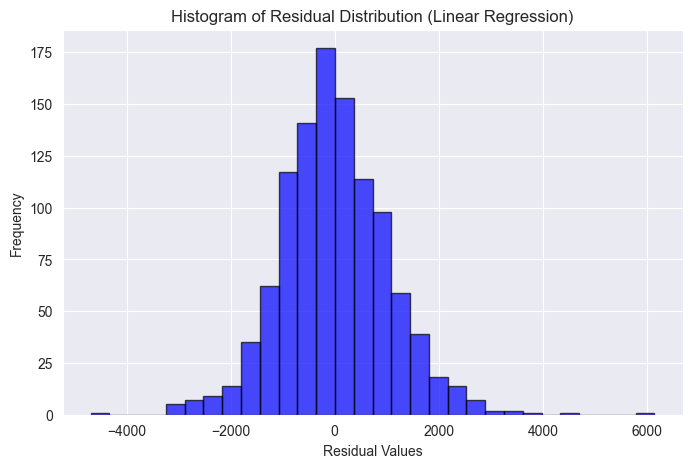

Kolmogorov-Smirnov statistic: 0.0364, P-value: 1.1288e-01
Hypothesis of normal residual distribution is ACCEPTED.


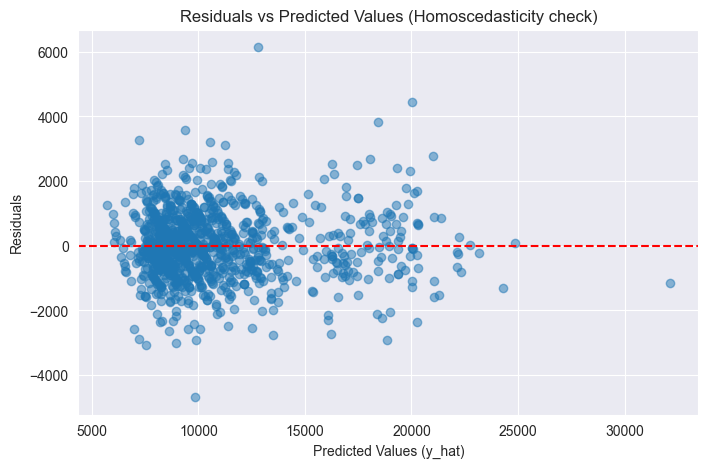

In [11]:
residuals = (y_train.ravel() - y_pred_linear_train.ravel())

def analyze_residuals(residuals, y_pred):
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
    plt.title('Histogram of Residual Distribution (Linear Regression)')
    plt.xlabel('Residual Values')
    plt.ylabel('Frequency')
    plt.show()

    residuals_mean = np.mean(residuals)
    residuals_std = np.std(residuals)
    theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

    statistic, p_value = kstest(residuals, theoretical_distribution.cdf)
    print(f"Kolmogorov-Smirnov statistic: {statistic:.4f}, P-value: {p_value:.4e}")

    alpha = 0.05
    if p_value < alpha:
        print("Hypothesis of normal residual distribution is REJECTED (residuals are not normal).")
    else:
        print("Hypothesis of normal residual distribution is ACCEPTED.")

    plt.figure(figsize=(8,5))
    plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residuals vs Predicted Values (Homoscedasticity check)')
    plt.xlabel("Predicted Values (y_hat)")
    plt.ylabel("Residuals")
    plt.show()

analyze_residuals(residuals, y_pred_linear_train)

## 5. Regularization with Hyperparameter Tuning (GridSearchCV)



In [12]:
ridge_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Ridge())
]
ridge_pipe = Pipeline(ridge_steps)

ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2000.0]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train.ravel())

best_ridge = ridge_grid.best_estimator_
print(f"Best alpha for Ridge: {ridge_grid.best_params_['model__alpha']}")

y_pred_ridge_train = best_ridge.predict(X_train)
y_pred_ridge_test = best_ridge.predict(X_test)

r2_score_ridge_train = r2_score(y_train, y_pred_ridge_train)
r2_score_ridge_test = r2_score(y_test, y_pred_ridge_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge_test)
cv_ridge = cross_val_score(estimator=best_ridge, X=X_train, y=y_train.ravel(), cv=10).mean()

print("Ridge Regression Results:")
print(f"R2 Score (train): {r2_score_ridge_train:.4f}")
print(f"R2 Score (test): {r2_score_ridge_test:.4f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"MAPE: {mape_ridge:.4f}")

Best alpha for Ridge: 10.0
Ridge Regression Results:
R2 Score (train): 0.9139
R2 Score (test): 0.8318
RMSE: 1545.06
MAPE: 0.0910


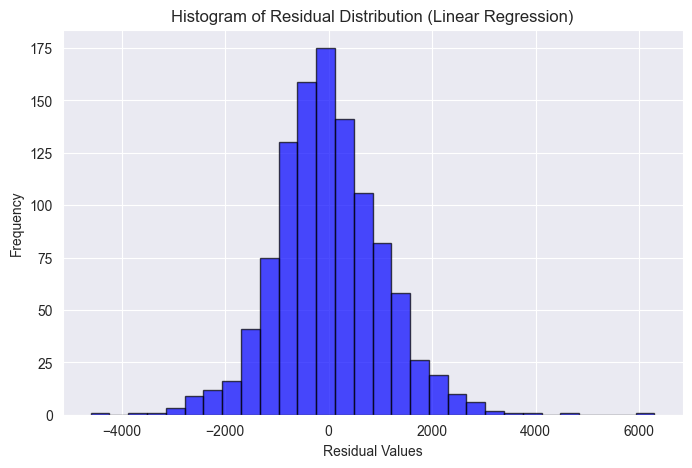

Kolmogorov-Smirnov statistic: 0.0363, P-value: 1.1499e-01
Hypothesis of normal residual distribution is ACCEPTED.


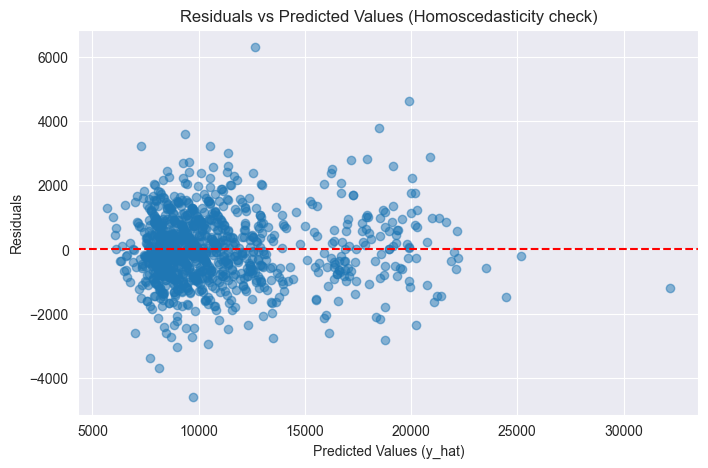

In [13]:
residuals_ridge = (y_train.ravel() - y_pred_ridge_train).ravel()
analyze_residuals(residuals_ridge, y_pred_ridge_train)

In [14]:
lasso_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Lasso(max_iter=5000))
]
lasso_pipe = Pipeline(lasso_steps)

lasso_param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train.ravel())

best_lasso = lasso_grid.best_estimator_
print(f"Best alpha for Lasso: {lasso_grid.best_params_['model__alpha']}")

y_pred_lasso_train = best_lasso.predict(X_train)
y_pred_lasso_test = best_lasso.predict(X_test)

r2_score_lasso_train = r2_score(y_train, y_pred_lasso_train)
r2_score_lasso_test = r2_score(y_test, y_pred_lasso_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso_test)
cv_lasso = cross_val_score(estimator=best_lasso, X=X_train, y=y_train.ravel(), cv=10).mean()

print("Lasso Regression Results:")
print(f"R2 Score (train): {r2_score_lasso_train:.4f}")
print(f"R2 Score (test): {r2_score_lasso_test:.4f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAPE: {mape_lasso:.4f}")

Best alpha for Lasso: 100.0
Lasso Regression Results:
R2 Score (train): 0.8965
R2 Score (test): 0.9081
RMSE: 1142.04
MAPE: 0.0896


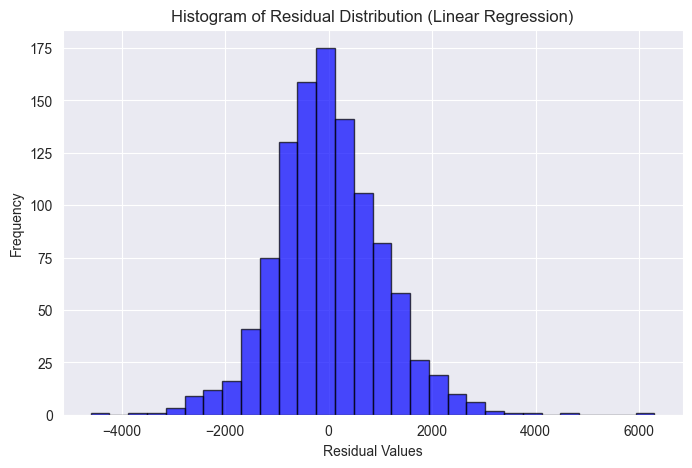

Kolmogorov-Smirnov statistic: 0.0363, P-value: 1.1499e-01
Hypothesis of normal residual distribution is ACCEPTED.


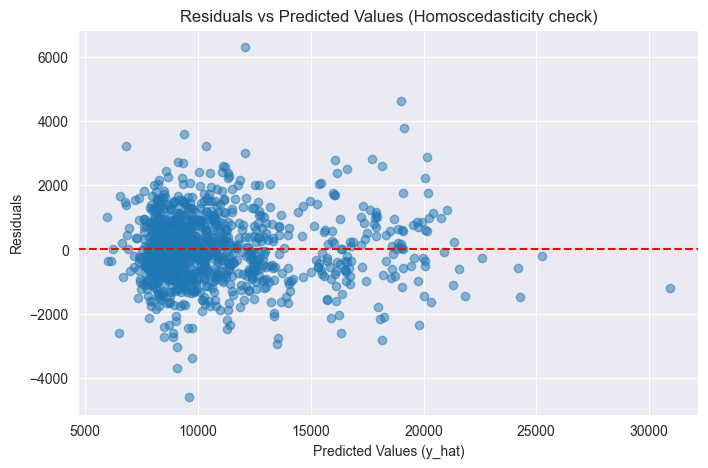

In [15]:
residuals_lasso = (y_train.ravel() - y_pred_lasso_train).ravel()
analyze_residuals(residuals_ridge, y_pred_lasso_train)

 ### Experiment: Removing Weakly Correlated Features (corr < 0.05)

Remove features that have almost no correlation with the target variable Price.

In [16]:
corr_matrix = dataset.corr(numeric_only=True)
target_corr = corr_matrix['Price'].abs()
threshold = 0.05
low_corr_cols = target_corr[target_corr <= threshold].index.tolist()

print(f"Features with correlation < {threshold} by absolute value: {low_corr_cols}")

if len(low_corr_cols) > 0:
    X_exp1 = dataset_encoded.drop(columns=['Price'] + low_corr_cols).values
    X_train_e1, X_test_e1, y_train_e1, y_test_e1 = train_test_split(X_exp1, y, test_size=0.25, random_state=42)

    lr_exp1 = LinearRegression()
    lr_exp1.fit(X_train_e1, y_train_e1)

    y_pred_e1 = lr_exp1.predict(X_test_e1)
    rmse_e1 = np.sqrt(mean_squared_error(y_test_e1, y_pred_e1))
    mape_e1 = mean_absolute_percentage_error(y_test_e1, y_pred_e1)
    r2_test_e1 = r2_score(y_test_e1, y_pred_e1)

    print(f"RMSE after removing weak features: {rmse_e1:.2f}")
    print(f"MAPE after removing weak features: {mape_e1:.4f}")
    print(f"R2 (test) after removing weak features: {r2_test_e1:.4f}")
else:
    print("No features with such weak correlation. Skipping experiment.")

Features with correlation < 0.05 by absolute value: ['Automatic']
RMSE after removing weak features: 1453.33
MAPE after removing weak features: 0.1008
R2 (test) after removing weak features: 0.8512


 ## 6. OLS vs Gradient Descent
 Demonstrate that a model trained with manual gradient descent converges to the same (or very close) results as the analytical OLS solution (LinearRegression). Standardization is mandatory for GD!

In [17]:
def add_const(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def gradient_descent(X, y, lr=0.01, iterations=5000):
    X_c = add_const(X)
    n, m = X_c.shape
    w = np.zeros(m)
    for k in range(iterations):
        grad = 2 / n * X_c.T @ (X_c @ w - y.ravel())
        w -= lr * grad
    return w

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

w_gd = gradient_descent(X_train_scaled, y_train_scaled, lr=0.01, iterations=4000)
y_pred_gd_scaled = add_const(X_test_scaled) @ w_gd
y_pred_gd = scaler_y.inverse_transform(y_pred_gd_scaled.reshape(-1, 1))

lr_scaled = LinearRegression(fit_intercept=True)
lr_scaled.fit(X_train_scaled, y_train_scaled.ravel())
w_ols = np.insert(lr_scaled.coef_, 0, lr_scaled.intercept_)
y_pred_ols_scaled = lr_scaled.predict(X_test_scaled)
y_pred_ols = scaler_y.inverse_transform(y_pred_ols_scaled.reshape(-1, 1))

print("Comparison of weights (w0, w1...):")
print(f"Gradient Descent: \n{w_gd[:5]} ...")
print(f"Analytical OLS: \n{w_ols[:5]} ...")

rmse_gd = np.sqrt(mean_squared_error(y_test, y_pred_gd))
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))

print(f"\nRMSE Gradient Descent: {rmse_gd:.4f}")
print(f"RMSE OLS (LinearRegression): {rmse_ols:.4f}")

Comparison of weights (w0, w1...):
Gradient Descent: 
[ 3.05065218e-16 -6.40457752e-01 -1.63261719e-01  7.92661307e-02
  1.20865620e-02] ...
Analytical OLS: 
[ 2.83429622e-16 -6.40514586e-01 -1.63218846e-01  7.94135289e-02
  1.20896024e-02] ...

RMSE Gradient Descent: 1450.4330
RMSE OLS (LinearRegression): 1450.3569


 Видим, что веса и ошибки у МНК и градиентного спуска идентичны (с точностью до погрешности итераций).

 ## 7. Final Results Table



In [18]:
models = [
    ('Linear Regression (Base)', rmse_linear, mape_linear, r2_score_linear_test),
    ('Ridge (GridSearchCV)', rmse_ridge, mape_ridge, r2_score_ridge_test),
    ('Lasso (GridSearchCV)', rmse_lasso, mape_lasso, r2_score_lasso_test),
    ('LR (Drop low corr)', rmse_e1 if len(low_corr_cols)>0 else None, mape_e1 if len(low_corr_cols)>0 else None, r2_test_e1 if len(low_corr_cols)>0 else None),
]

predict_df = pd.DataFrame(data=models, columns=['Model', 'RMSE', 'MAPE', 'R2_Score(test)'])
display(predict_df)

,Model,RMSE,MAPE,R2_Score(test)
0,Linear Regression (Base),1797.885265,0.094590,0.772221
1,Ridge (GridSearchCV),1545.061873,0.091001,0.831778
2,Lasso (GridSearchCV),1142.036315,0.089568,0.908093
3,LR (Drop low corr),1453.332845,0.100794,0.851160


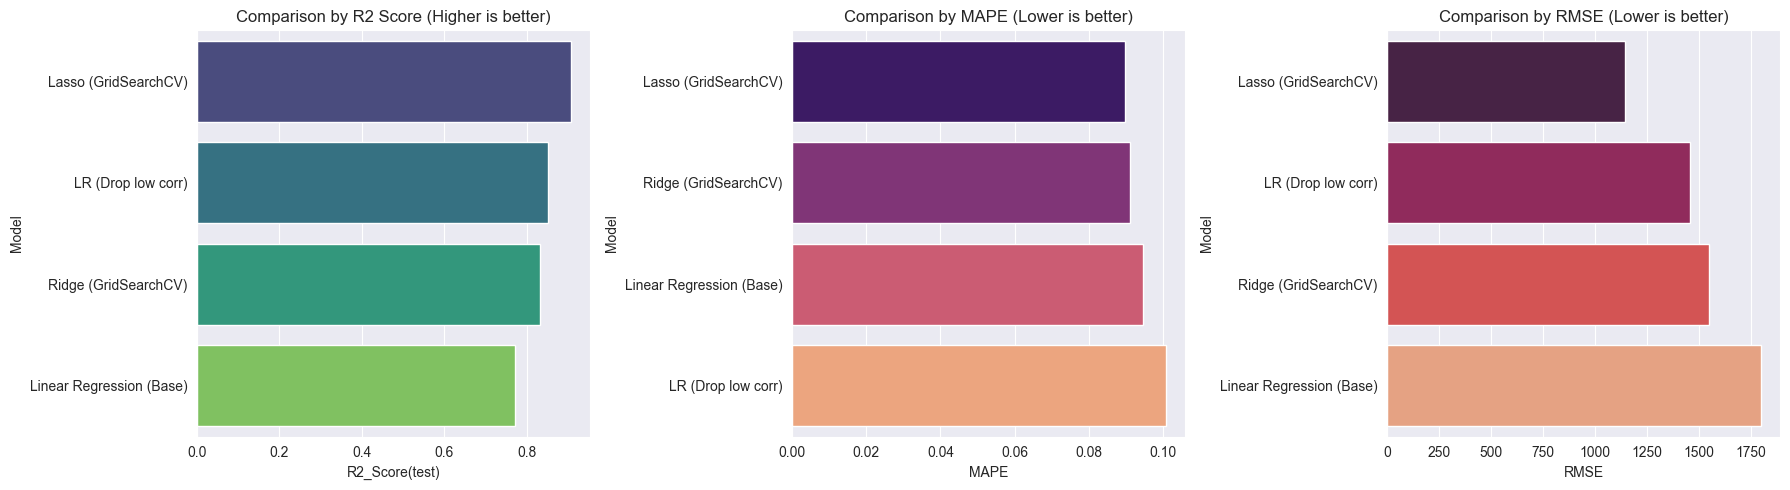

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Comparison by R2 Score (Higher is better)')

sns.barplot(x='MAPE', y='Model', data=predict_df.sort_values('MAPE'), ax=axes[1], palette='magma')
axes[1].set_title('Comparison by MAPE (Lower is better)')

sns.barplot(x='RMSE', y='Model', data=predict_df.sort_values('RMSE'), ax=axes[2], palette='rocket')
axes[2].set_title('Comparison by RMSE (Lower is better)')

plt.tight_layout()
plt.show()

In [20]:
dataset = pd.read_csv('./ToyotaCorolla.csv')

dataset = dataset[selected_columns]

dataset.head()

,Age_08_04,KM,Fuel_Type,HP,Met_Color,Automatic,CC,Doors,Weight,Price
0,23,46986,Diesel,90,1,0,2000,3,1165,13500
1,23,72937,Diesel,90,1,0,2000,3,1165,13750
2,24,41711,Diesel,90,1,0,2000,3,1165,13950
3,26,48000,Diesel,90,0,0,2000,3,1165,14950
4,30,38500,Diesel,90,0,0,2000,3,1170,13750


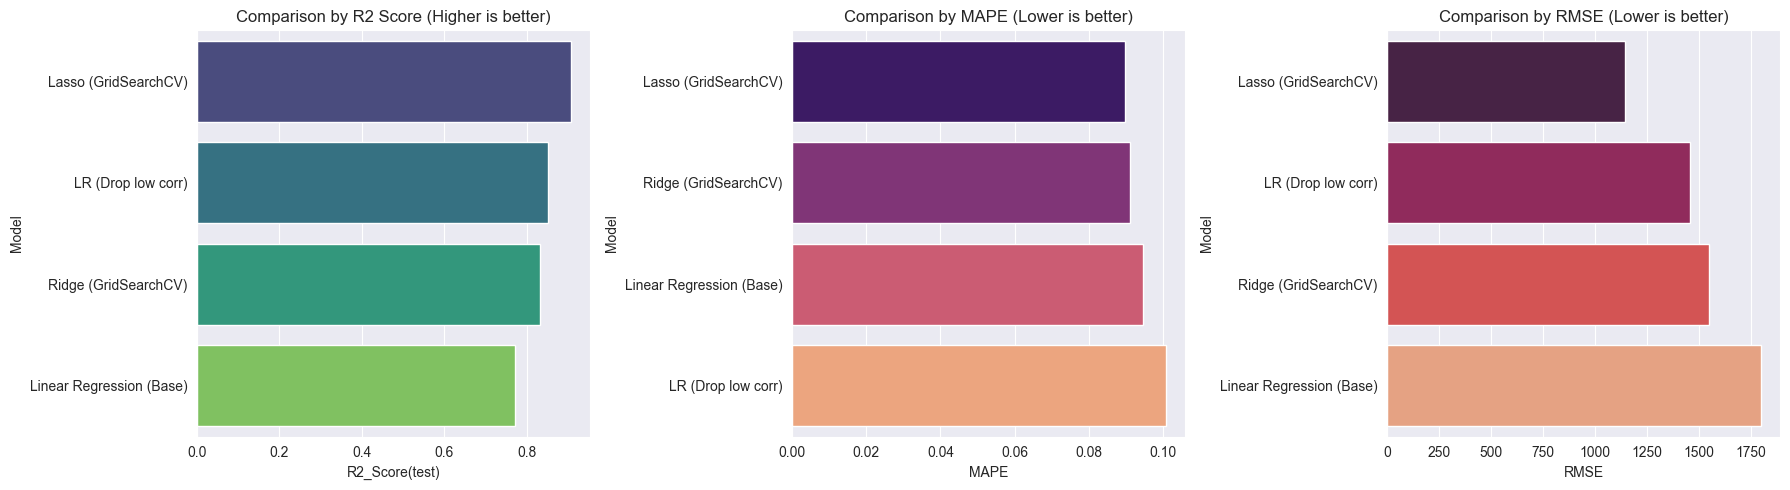

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Comparison by R2 Score (Higher is better)')

sns.barplot(x='MAPE', y='Model', data=predict_df.sort_values('MAPE'), ax=axes[1], palette='magma')
axes[1].set_title('Comparison by MAPE (Lower is better)')

sns.barplot(x='RMSE', y='Model', data=predict_df.sort_values('RMSE'), ax=axes[2], palette='rocket')
axes[2].set_title('Comparison by RMSE (Lower is better)')

plt.tight_layout()
plt.show()

## Как вы предобрабатывали данные?

некоторые колонки переименовал, убрал пропуски, закодировал признаки категориальные, отделил price

## Что вы поняли, проведя EDA?

Age и KM сильно отрицательно коррелируют с Price, Weight и HP положительно коррелируют с ценой

## Как вы работали с признаками?

применили StandardScaler
удалил признаки с корреляцией <0.05 с price

## Какие признаки удалили и почему?

в эксперименте удалили признаки с corr < 0.05

## Как именно вы разделили выборку?

train_test_split с test_size=0.25 и random_state=42

## Для чего это нужно? Зачем мы вообще отделяем часть данных и почему нельзя обучать и проверять модель на одном и том же наборе?

потомучто модель учит все зависимости на конкретном датасете и если не проверить то может возникнуть проблема переобучения, поэтому надо проверять. работу на новых данных в нашем случае на данных которые мы как бы прячемё

## Как проходило обучение моделей?

сначала просто обучили модель потом регуляризация потом сравнивали после улучшения по граиенту и по олс

## Сравнение скорости

быстрее всех — обычная линейная регрессия
GridSearchCV для Ridge/Lasso медленнее

## Какие метрики вы использовали для сравнения? Почему?

RMSE - интерпретируемая ошибка в единицах цены. штрафует большие ошибки сильнее, чем MAE
MAPE - относительная ошибка в %

## На какой части выборки считали метрики?

на трейне и тесте и потом сравнивали

## Лучшие модели

Ridge и обычная регрессия 

## Насколько хорошие результаты?

ошибка порядка ~10%

## Чем докажете, что ваша модель не переобучилась?

на тесте хорошие результаты
